<a href="https://colab.research.google.com/github/janumpallyhansika-glitch/ML/blob/main/Titanic_EDA_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [ ]:
df = sns.load_dataset("titanic")

In [ ]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
df_original = df.copy()

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 15)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


Step 1: Define the Problem

The objective of this analysis is to understand the Titanic passenger
dataset and identify factors associated with passenger survival.

Target Variable:
Survived

0 = Did not survive
1 = Survived

In [ ]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


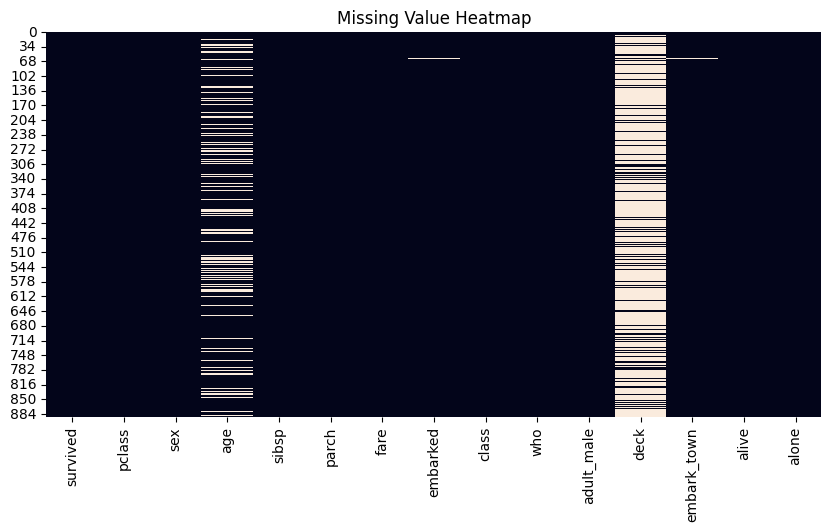

In [ ]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

df = df.drop(columns=['deck'], errors='ignore')

In [ ]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 116


In [ ]:
df = df.drop_duplicates()

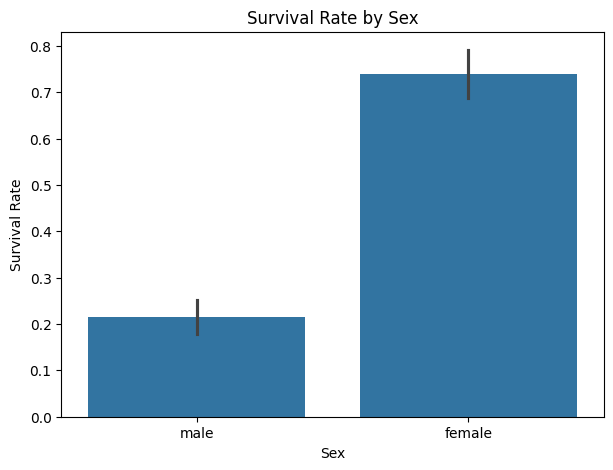

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
print(df.groupby("sex")["survived"].mean())

sex
female    0.739726
male      0.215321
Name: survived, dtype: float64


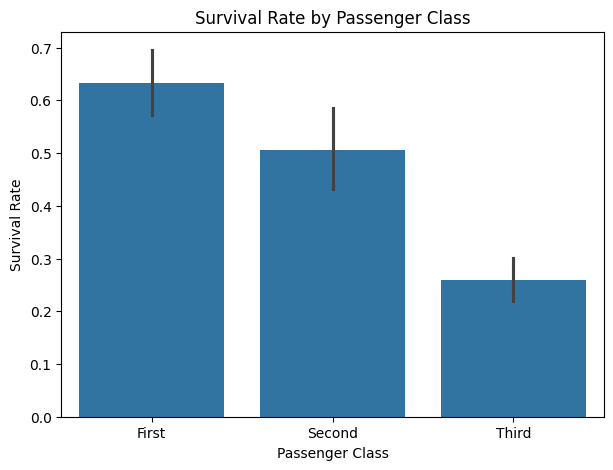

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="class",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
print(df.groupby("class")["survived"].mean())

class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64


/tmp/ipykernel_561/571054476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["survived"].mean())


In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

In [ ]:
print(df["age_group"].value_counts())

age_group
Young Adult    428
Adult          191
Child           68
Teen            67
Senior          21
Name: count, dtype: int64


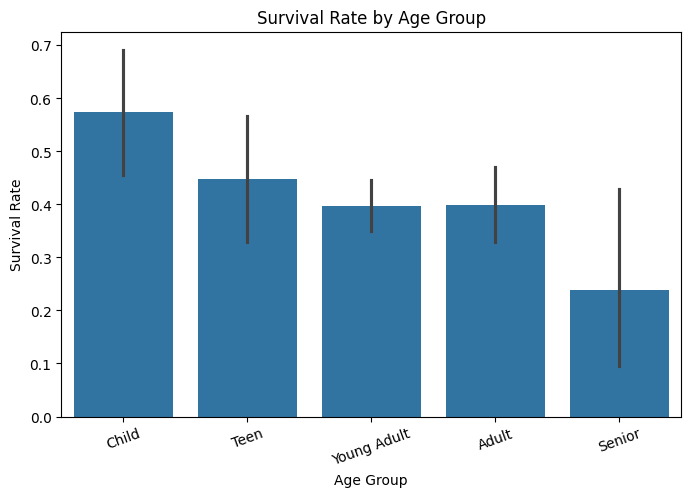

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="age_group",
    y="survived"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.xticks(rotation=20)

plt.show()

In [ ]:
print(
    df.groupby(
        "age_group",
        observed=True
    )["survived"].mean()
)

age_group
Child          0.573529
Teen           0.447761
Young Adult    0.397196
Adult          0.397906
Senior         0.238095
Name: survived, dtype: float64


In [ ]:
lifecycle_mapping = {
    "Child": "0-12 years",
    "Teen": "13-18 years",
    "Young Adult": "19-35 years",
    "Adult": "36-60 years",
    "Senior": "61+ years"
}

print(lifecycle_mapping)

{'Child': '0-12 years', 'Teen': '13-18 years', 'Young Adult': '19-35 years', 'Adult': '36-60 years', 'Senior': '61+ years'}


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

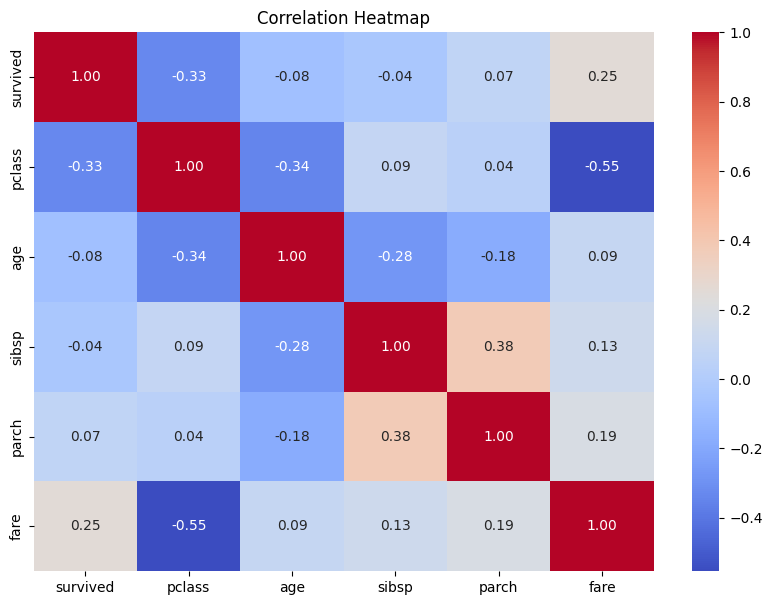

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
with PdfPages("titanic_eda_report.pdf") as pdf:

    # =========================
    # PAGE 1
    # Dataset + Missing Values
    # =========================

    fig = plt.figure(figsize=(11, 8.5))

    plt.subplot(2, 1, 1)

    plt.axis("off")

    information = (
        "TITANIC EDA REPORT\n\n"
        f"Dataset Shape: {df.shape}\n\n"
        "Objective:\n"
        "Analyze the Titanic dataset and understand factors "
        "associated with passenger survival.\n\n"
        "Target Variable: Survived\n"
        "0 = Did Not Survive\n"
        "1 = Survived"
    )

    plt.text(
        0.05,
        0.5,
        information,
        fontsize=12,
        va="center"
    )

    plt.subplot(2, 1, 2)

    sns.heatmap(
        df.isnull(),
        cbar=False
    )

    plt.title("Missing Value Heatmap")

    plt.tight_layout()

    pdf.savefig(fig)
    plt.close()


    # =========================
    # PAGE 2
    # Sex + Class
    # =========================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5)
    )

    sns.barplot(
        data=df,
        x="sex",
        y="survived",
        ax=axes[0]
    )

    axes[0].set_title(
        "Survival Rate by Sex"
    )

    axes[0].set_xlabel("Sex")
    axes[0].set_ylabel("Survival Rate")


    sns.barplot(
        data=df,
        x="class",
        y="survived",
        ax=axes[1]
    )

    axes[1].set_title(
        "Survival Rate by Passenger Class"
    )

    axes[1].set_xlabel("Passenger Class")
    axes[1].set_ylabel("Survival Rate")

    plt.tight_layout()

    pdf.savefig(fig)
    plt.close()


    # =========================
    # PAGE 3
    # Age + Lifecycle
    # =========================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5)
    )

    sns.barplot(
        data=df,
        x="age_group",
        y="survived",
        ax=axes[0]
    )

    axes[0].set_title(
        "Survival Rate by Age Group"
    )

    axes[0].set_xlabel("Age Group")
    axes[0].set_ylabel("Survival Rate")

    axes[0].tick_params(
        axis="x",
        rotation=25
    )


    axes[1].axis("off")

    lifecycle_text = (
        "LIFECYCLE MAPPING\n\n"
        "Child       : 0-12 years\n"
        "Teen        : 13-18 years\n"
        "Young Adult : 19-35 years\n"
        "Adult       : 36-60 years\n"
        "Senior      : 61+ years"
    )

    axes[1].text(
        0.1,
        0.5,
        lifecycle_text,
        fontsize=13,
        va="center"
    )

    plt.tight_layout()

    pdf.savefig(fig)
    plt.close()


    # =========================
    # PAGE 4
    # Correlation
    # =========================

    fig, ax = plt.subplots(
        figsize=(11, 8)
    )

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        ax=ax
    )

    ax.set_title(
        "Correlation Heatmap"
    )

    plt.tight_layout()

    pdf.savefig(fig)
    plt.close()


print("PDF created successfully!")
print("File name: titanic_eda_report.pdf")

PDF created successfully!
File name: titanic_eda_report.pdf
